<a href="https://colab.research.google.com/github/kalingasajja/FAS-deepfake-capstone/blob/Rohith/Capstonev2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define NEW permanent output directory
OUT_DIR = '/content/drive/MyDrive/baseline_v2/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# 3. Define FAST LOCAL storage for the dataset
LOCAL_DATA_DIR = '/content/raw_data_v2'
os.makedirs(LOCAL_DATA_DIR, exist_ok=True)

print(f"Outputs will save permanently to: {OUT_DIR}")
print(f"Data will extract instantly to: {LOCAL_DATA_DIR}")

Mounted at /content/drive
Outputs will save permanently to: /content/drive/MyDrive/baseline_v2/outputs
Data will extract instantly to: /content/raw_data_v2


Fetch & Extract the ciplab Dataset

In [2]:
import os

# 1. Credentials (Replace username)
os.environ['KAGGLE_USERNAME'] = 'rohithgudimetla'
os.environ['KAGGLE_KEY'] = 'KGAT_baf10636c9b95e0b603be36a99244bd6'

# 2. Download zip to local /content
print("Downloading ciplab dataset...")
!kaggle datasets download -d ciplab/real-and-fake-face-detection -p /content

# 3. Extract to local folder
print("Extracting images...")
!unzip -q -n /content/real-and-fake-face-detection.zip -d {LOCAL_DATA_DIR}
print("Extraction complete in local storage.")

Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0
100% 431M/431M [00:25<00:00, 17.9MB/s]

Extracting images...
Extraction complete in local storage.


80/20 Split & DataLoaders

In [3]:
import torch
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# The Kaggle zip creates this specific subfolder
DATASET_PATH = os.path.join(LOCAL_DATA_DIR, 'real_and_fake_face')

# 1. SigLIP transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# 2. Load dataset
full_dataset = datasets.ImageFolder(root=DATASET_PATH, transform=transform)
print(f"Classes found: {full_dataset.class_to_idx}")

# 3. Apply 80/20 split
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

# 4. Initialize DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Ready: {train_size} training images, {test_size} testing images.")

Classes found: {'training_fake': 0, 'training_real': 1}
Ready: 1632 training images, 409 testing images.


Feature extracting SigLIP Model & MLP  & Optimizer

In [4]:
import torch
import torch.nn as nn
from transformers import SiglipVisionModel

class SpatialDeepfakeDetector(nn.Module):
    def __init__(self):
        super().__init__()
        # Load the pre-trained SigLIP backbone
        self.backbone = SiglipVisionModel.from_pretrained("google/siglip-base-patch16-224")

        # Freeze the backbone so we only train the MLP head
        for param in self.backbone.parameters():
            param.requires_grad = False

        # 2-Layer MLP Classification Head
        self.head = nn.Sequential(
            nn.Linear(768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, pixel_values):
        # Extract features (pooler_output is the global representation)
        outputs = self.backbone(pixel_values=pixel_values)
        # Pass the 768-dim embeddings through the head to get a single logit
        return self.head(outputs.pooler_output)

# 1. Initialize model and set device to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = SpatialDeepfakeDetector().to(device)

# 2. Setup Loss and Optimizer (ONLY optimizing the head parameters)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.head.parameters(), lr=1e-4)

print("Model initialized, backbone frozen, and optimizer ready.")

Using device: cuda


config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  813MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.final_layer_norm.bias                             | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.lay

Model initialized, backbone frozen, and optimizer ready.


Training Loop of Model

In [5]:
from tqdm import tqdm

# Configuration
epochs = 10
OUT_DIR = '/content/drive/MyDrive/baseline_v2/outputs'
weights_path = os.path.join(OUT_DIR, 'spatial_mlp_weights.pth')

# Initialize the gradient scaler for AMP
scaler = torch.amp.GradScaler('cuda')

model.train()
for epoch in range(epochs):
    epoch_loss = 0.0

    # Wrap the loader in tqdm for a clean progress bar
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in progress_bar:
        # Move inputs to GPU
        images = images.to(device)

        # BCEWithLogitsLoss expects labels to be floats and matching the logit shape [batch_size, 1]
        labels = labels.to(device).float().unsqueeze(1)

        optimizer.zero_grad()

        # 1. Forward pass under AMP context
        with torch.amp.autocast('cuda'):
            logits = model(images)
            loss = criterion(logits, labels)

        # 2. Backward pass scaling the loss to prevent underflow
        scaler.scale(loss).backward()

        # 3. Optimizer step and scaler update
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

        # Update progress bar with the current batch loss
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    # Calculate and print average loss for the epoch
    avg_epoch_loss = epoch_loss / len(train_loader)
    print(f"Epoch {epoch+1} Completed | Average Loss: {avg_epoch_loss:.4f}\n")

# Save ONLY the trained head parameters permanently
torch.save(model.head.state_dict(), weights_path)
print(f"Training complete! Weights permanently saved to: {weights_path}")

Epoch 1/10: 100%|██████████| 51/51 [00:19<00:00,  2.58it/s, loss=0.6453]


Epoch 1 Completed | Average Loss: 0.6832



Epoch 2/10: 100%|██████████| 51/51 [00:20<00:00,  2.43it/s, loss=0.7047]


Epoch 2 Completed | Average Loss: 0.6585



Epoch 3/10: 100%|██████████| 51/51 [00:23<00:00,  2.20it/s, loss=0.6128]


...

Epoch 8 Completed | Average Loss: 0.5582



Epoch 9/10: 100%|██████████| 51/51 [00:16<00:00,  3.02it/s, loss=0.5062]


Epoch 9 Completed | Average Loss: 0.5510



Epoch 10/10: 100%|██████████| 51/51 [00:16<00:00,  3.02it/s, loss=0.4923]

Epoch 10 Completed | Average Loss: 0.5369

Training complete! Weights permanently saved to: /content/drive/MyDrive/baseline_v2/outputs/spatial_mlp_weights.pth


Evaluation & Metrics

Evaluating Test Split: 100%|██████████| 13/13 [00:11<00:00,  1.14it/s]



 STANDALONE SPATIAL BRANCH EVALUATION METRICS 
Test_Loss                : 0.5915
Accuracy                 : 0.6748
Precision                : 0.7208
Recall_Sensitivity       : 0.6455
Specificity              : 0.7090
F1_Score                 : 0.6811
AUC_ROC                  : 0.7551
Average_Precision_PR_AUC : 0.7629
True_Negatives           : 134
False_Positives          : 55
False_Negatives          : 78
True_Positives           : 142

[Saved] Evaluation metrics CSV: /content/drive/MyDrive/baseline_v2/outputs/spatial_evaluation_metrics.csv


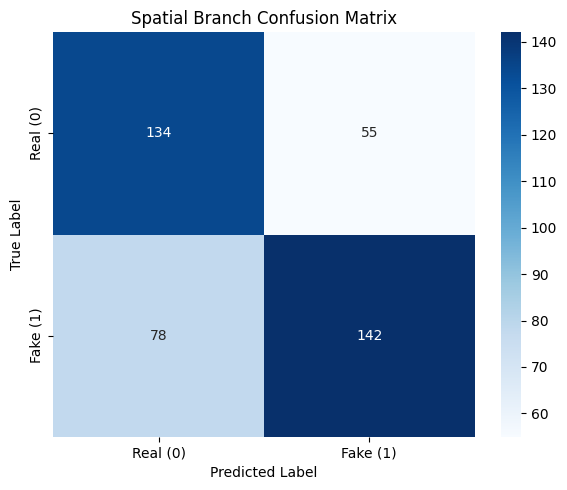

[Saved] Confusion Matrix graphic: /content/drive/MyDrive/baseline_v2/outputs/spatial_confusion_matrix.png


In [6]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Define permanent output path
OUT_DIR = '/content/drive/MyDrive/baseline_v2/outputs'
os.makedirs(OUT_DIR, exist_ok=True)

# Switch model to evaluation mode (disables Dropout)
model.eval()

test_loss = 0.0
all_labels = []
all_probs = []
all_preds = []

# Iterate over the test dataset
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Evaluating Test Split"):
        images = images.to(device)
        labels_float = labels.to(device).float().unsqueeze(1)

        # Forward pass
        logits = model(images)
        loss = criterion(logits, labels_float)
        test_loss += loss.item()

        # Compute probabilities via Sigmoid
        probs = torch.sigmoid(logits).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)

        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        all_preds.extend(preds)

avg_test_loss = test_loss / len(test_loader)

# Confusion Matrix Breakdown (True Negatives, False Positives, False Negatives, True Positives)
tn, fp, fn, tp = confusion_matrix(all_labels, all_preds).ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

# Comprehensive Metrics Dictionary
metrics = {
    "Test_Loss": avg_test_loss,
    "Accuracy": accuracy_score(all_labels, all_preds),
    "Precision": precision_score(all_labels, all_preds, zero_division=0),
    "Recall_Sensitivity": recall_score(all_labels, all_preds, zero_division=0),
    "Specificity": specificity,
    "F1_Score": f1_score(all_labels, all_preds, zero_division=0),
    "AUC_ROC": roc_auc_score(all_labels, all_probs),
    "Average_Precision_PR_AUC": average_precision_score(all_labels, all_probs),
    "True_Negatives": tn,
    "False_Positives": fp,
    "False_Negatives": fn,
    "True_Positives": tp
}

# 1. Print formatted results
print("\n" + "="*45)
print(" STANDALONE SPATIAL BRANCH EVALUATION METRICS ")
print("="*45)
for key, val in metrics.items():
    if isinstance(val, float):
        print(f"{key:25s}: {val:.4f}")
    else:
        print(f"{key:25s}: {val}")

# 2. Save CSV report to Google Drive
csv_path = os.path.join(OUT_DIR, 'spatial_evaluation_metrics.csv')
pd.DataFrame([metrics]).to_csv(csv_path, index=False)
print(f"\n[Saved] Evaluation metrics CSV: {csv_path}")

# 3. Generate and save Confusion Matrix plot
plt.figure(figsize=(6, 5))
cm = np.array([[tn, fp], [fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Real (0)', 'Fake (1)'],
            yticklabels=['Real (0)', 'Fake (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Spatial Branch Confusion Matrix')
plt.tight_layout()

cm_path = os.path.join(OUT_DIR, 'spatial_confusion_matrix.png')
plt.savefig(cm_path, dpi=300)
plt.show()
print(f"[Saved] Confusion Matrix graphic: {cm_path}")